In [16]:
import sys
import pandas as pd
import numpy as np
import sklearn
import matplotlib
import seaborn as sns

print("Library Versions")
print("-" * 40)
print(f"Pandas         : {pd.__version__}")
print(f"NumPy          : {np.__version__}")
print(f"Scikit-learn   : {sklearn.__version__}")
print(f"Matplotlib     : {matplotlib.__version__}")
print(f"Seaborn        : {sns.__version__}")

Library Versions
----------------------------------------
Pandas         : 2.2.2
NumPy          : 2.0.2
Scikit-learn   : 1.6.1
Matplotlib     : 3.10.0
Seaborn        : 0.13.2


In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.backends.backend_pdf import PdfPages

# Step 1: Load Titanic Dataset

In [18]:
from pandas import read_csv
from google.colab import files
import io

print("Please upload the 'Titanic-Dataset.csv")
uploaded = files.upload()

for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))
  df = read_csv(io.StringIO(uploaded[fn].decode('utf-8')))

Please upload the 'Titanic-Dataset.csv


Saving Titanic-Dataset.csv to Titanic-Dataset.csv
User uploaded file "Titanic-Dataset.csv" with length 61194 bytes


# Step 2: Understand the Data

In [20]:
print('--- First 5 rows of the dataset ---')
display(df.head())

--- First 5 rows of the dataset ---


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [21]:
print('\n--- Dataset Shape ---')
print(df.shape)


--- Dataset Shape ---
(891, 12)


In [22]:
print('\n--- Dataset Info ---')
df.info()


--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [23]:
print('\n--- Dataset Description ---')
display(df.describe())


--- Dataset Description ---


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


# Step 3: Clean the Data

### Missing Value Heatmap

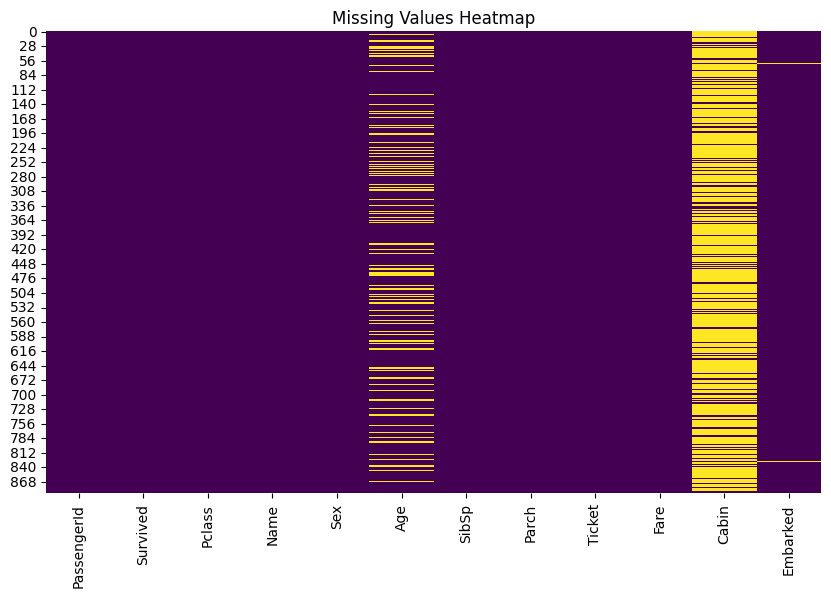

In [24]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()

## Survival Analysis

### Survival by Sex

Survival Rate by Sex:
Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64


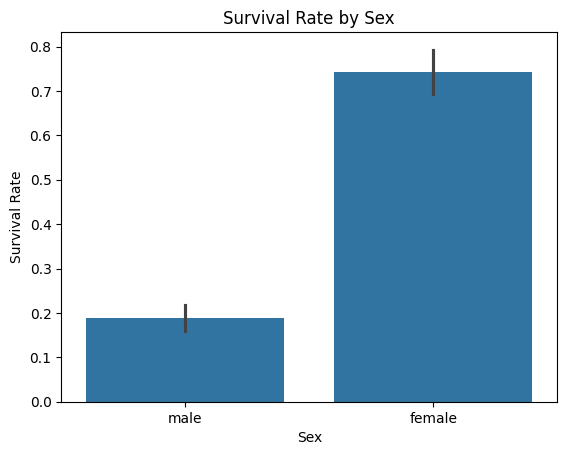

In [25]:
print('Survival Rate by Sex:')
print(df.groupby('Sex')['Survived'].mean())

sns.barplot(x='Sex', y='Survived', data=df)
plt.title('Survival Rate by Sex')
plt.ylabel('Survival Rate')
plt.show()

### Survival by Passenger Class (Pclass)


Survival Rate by Pclass:
Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64


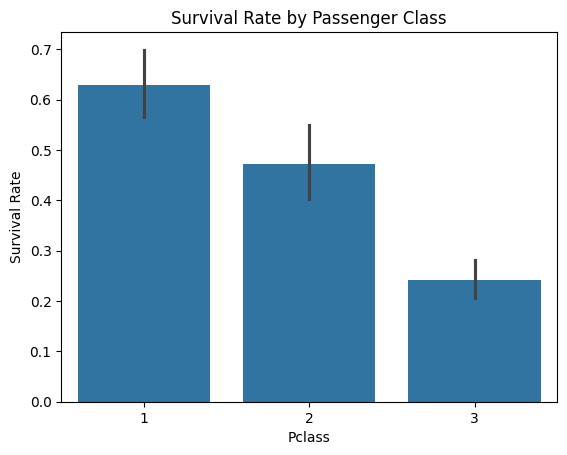

In [26]:
print('\nSurvival Rate by Pclass:')
print(df.groupby('Pclass')['Survived'].mean())

sns.barplot(x='Pclass', y='Survived', data=df)
plt.title('Survival Rate by Passenger Class')
plt.ylabel('Survival Rate')
plt.show()

### Survival by Age Group


Survival Rate by Age Group:
AgeGroup
Child       0.573529
Teenager    0.488889
Adult       0.386087
Elderly     0.269231
Name: Survived, dtype: float64


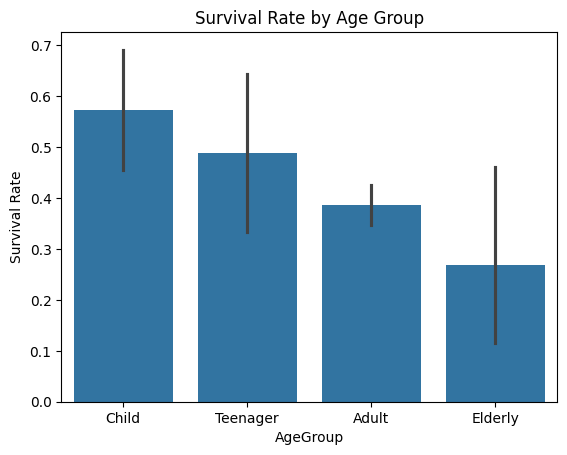

In [33]:
bins = [0, 12, 18, 60, 100]
labels = ['Child', 'Teenager', 'Adult', 'Elderly']
df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels, right=False)

print('\nSurvival Rate by Age Group:')
print(df.groupby('AgeGroup', observed=False)['Survived'].mean())

sns.barplot(x='AgeGroup', y='Survived', data=df)
plt.title('Survival Rate by Age Group')
plt.ylabel('Survival Rate')
plt.show()

## Lifecycle Mapping Dictionary

In [28]:
# Define mapping dictionaries for better readability
survived_map = {0: 'Perished', 1: 'Survived'}
sex_map = {'male': 'Male', 'female': 'Female'}
pclass_map = {1: 'First Class', 2: 'Second Class', 3: 'Third Class'}

# Apply mappings to create new descriptive columns (optional, but good for reporting)
df['Survived_Desc'] = df['Survived'].map(survived_map)
df['Sex_Desc'] = df['Sex'].map(sex_map)
df['Pclass_Desc'] = df['Pclass'].map(pclass_map)

print("Mapping Dictionaries Created and Applied:")
print("Survived Mapping:", survived_map)
print("Sex Mapping:", sex_map)
print("Pclass Mapping:", pclass_map)

print("\nFirst 5 rows with new descriptive columns:")
display(df[['Survived', 'Survived_Desc', 'Sex', 'Sex_Desc', 'Pclass', 'Pclass_Desc']].head())

Mapping Dictionaries Created and Applied:
Survived Mapping: {0: 'Perished', 1: 'Survived'}
Sex Mapping: {'male': 'Male', 'female': 'Female'}
Pclass Mapping: {1: 'First Class', 2: 'Second Class', 3: 'Third Class'}

First 5 rows with new descriptive columns:


,Survived,Survived_Desc,Sex,Sex_Desc,Pclass,Pclass_Desc
0,0,Perished,male,Male,3,Third Class
1,1,Survived,female,Female,1,First Class
2,1,Survived,female,Female,3,Third Class
3,1,Survived,female,Female,1,First Class
4,0,Perished,male,Male,3,Third Class


## Correlation Heatmap

### Handling Missing Values for Correlation (Age Imputation)

In [34]:
df_corr = df.copy()
# Impute missing 'Age' values with the median for correlation calculation
median_age = df_corr['Age'].median()
df_corr['Age'] = df_corr['Age'].fillna(median_age)
print(f"Missing 'Age' values imputed with median: {median_age:.2f}")

# Drop 'Cabin' column for correlation as it has too many missing values and is categorical
df_corr = df_corr.drop(columns=['Cabin', 'AgeGroup', 'Survived_Desc', 'Sex_Desc', 'Pclass_Desc'], errors='ignore')

# Convert categorical 'Sex' and 'Embarked' into numerical using one-hot encoding for correlation if desired
# For simplicity, we will just consider numerical columns first. If more detailed correlation is needed, one-hot encode.

# Select only numerical columns for correlation matrix
numerical_df_corr = df_corr.select_dtypes(include=['number'])

print("\nCorrelation Matrix:")
display(numerical_df_corr.corr())

Missing 'Age' values imputed with median: 28.00

Correlation Matrix:


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
PassengerId,1.000000,-0.005007,-0.035144,0.034212,-0.057527,-0.001652,0.012658
Survived,-0.005007,1.000000,-0.338481,-0.064910,-0.035322,0.081629,0.257307
Pclass,-0.035144,-0.338481,1.000000,-0.339898,0.083081,0.018443,-0.549500
Age,0.034212,-0.064910,-0.339898,1.000000,-0.233296,-0.172482,0.096688
SibSp,-0.057527,-0.035322,0.083081,-0.233296,1.000000,0.414838,0.159651
Parch,-0.001652,0.081629,0.018443,-0.172482,0.414838,1.000000,0.216225
Fare,0.012658,0.257307,-0.549500,0.096688,0.159651,0.216225,1.000000


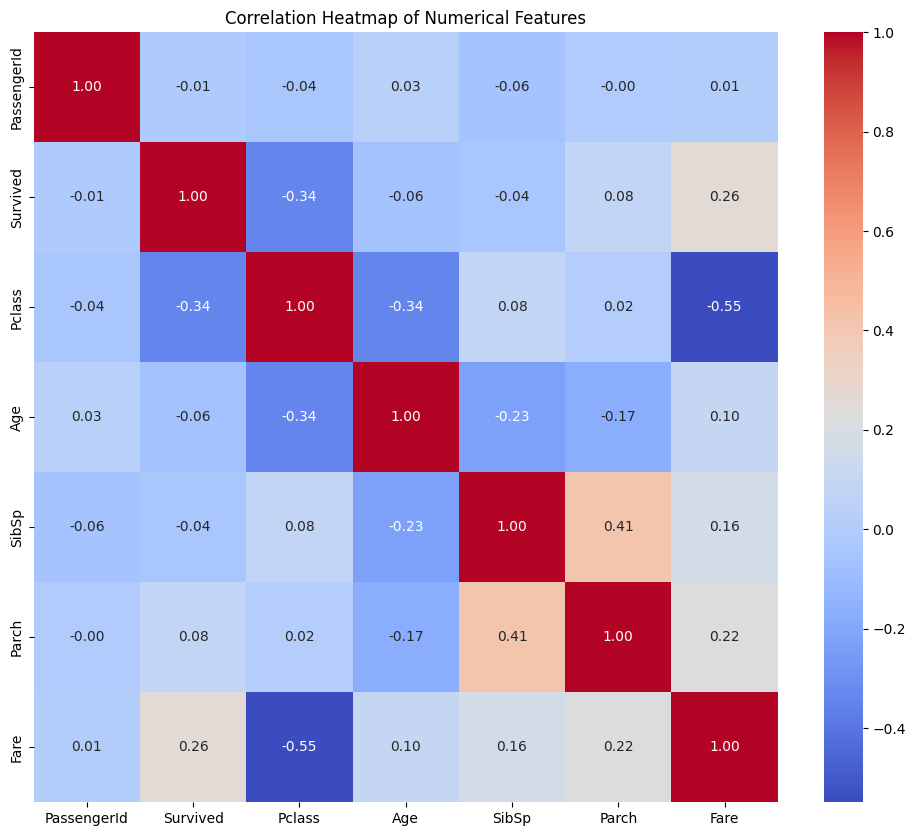

In [30]:
plt.figure(figsize=(12, 10))
sns.heatmap(numerical_df_corr.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

## Exporting Report to PDF

In [32]:
report_filename = 'titanic_eda_report.pdf'

with PdfPages(report_filename) as pdf:
    # Page 1: Missing Values Heatmap
    fig1 = plt.figure(figsize=(10, 6))
    sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
    plt.title('Missing Values Heatmap')
    plt.tight_layout()
    pdf.savefig(fig1)
    plt.close(fig1)

    # Page 2: Survival Analysis (Sex and Pclass)
    fig2, axes = plt.subplots(1, 2, figsize=(14, 6))

    sns.barplot(x='Sex', y='Survived', data=df, ax=axes[0])
    axes[0].set_title('Survival Rate by Sex')
    axes[0].set_ylabel('Survival Rate')

    sns.barplot(x='Pclass', y='Survived', data=df, ax=axes[1])
    axes[1].set_title('Survival Rate by Passenger Class')
    axes[1].set_ylabel('Survival Rate')

    plt.tight_layout()
    pdf.savefig(fig2)
    plt.close(fig2)

    # Page 3: Survival Analysis (Age Group)
    fig3 = plt.figure(figsize=(8, 6))
    sns.barplot(x='AgeGroup', y='Survived', data=df)
    plt.title('Survival Rate by Age Group')
    plt.ylabel('Survival Rate')
    plt.tight_layout()
    pdf.savefig(fig3)
    plt.close(fig3)

    # Page 4: Correlation Heatmap
    # Re-calculate numerical_df_corr to ensure it's up-to-date
    df_corr_final = df.copy()
    median_age_final = df_corr_final['Age'].median()
    df_corr_final['Age'] = df_corr_final['Age'].fillna(median_age_final)
    df_corr_final = df_corr_final.drop(columns=['Cabin', 'AgeGroup', 'Survived_Desc', 'Sex_Desc', 'Pclass_Desc'], errors='ignore')
    numerical_df_corr_final = df_corr_final.select_dtypes(include=['number'])

    fig4 = plt.figure(figsize=(12, 10))
    sns.heatmap(numerical_df_corr_final.corr(), annot=True, cmap='coolwarm', fmt='.2f')
    plt.title('Correlation Heatmap of Numerical Features')
    plt.tight_layout()
    pdf.savefig(fig4)
    plt.close(fig4)

print(f"Report saved as '{report_filename}'")

Report saved as 'titanic_eda_report.pdf'
